# Where'd He Come From? Where'd He Go?: Wide Receiver Route Classification
#### Parker Loupessis

 https://github.com/parloups/csci0451-loupessis-finalproject.git

In [11]:
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

## Abstract
This project attempted to classify wide receiver routes based on their (x,y) coordinates, speed, and direction throughout the play. The models used were all GRU RNNs with two layers and 64 hidden states. The first model used the (x, y) coordinates of the WR throughout the play and the snap location with the targets as basic route labels (go, in, out, curl), and acheived 67% accuracy on test data. The second model added WR's speed and direction, achieving 74% accuracy on test data. The third model used relative coordinates of the WR to the snap and augmented data, achieving 82% accuracy on test data. The fourth and final model used the same features as the third, but tried to predict different targets. These targets were the "true" route labels (post, slant, dig, ...) and the model achieved 45% accuracy on test data.

## Introduction
Football teams, at all levels, spend lots of time breaking down film to gather statistics that help diagnose tendencies and lead to a better understanding of opponents and themselves. This project aims to take a first step towards speeding up that long process, so that more time can be spent on analyzing the results.

The NFL has turned into a passing league, in which almost all offenses call more passing plays than running plays. These passing plays have each WR run a specific route. By labeling the route each of them ran, we could then expand upon this to label the play that was called. This would mean nearly cutting the time spent breaking down film in half (as there are still other important parts to passing plays). It would also be a proof of concept—providing evidence that something like this could be done.

This task is not unique to this project, as the 2019 NFL Big Data Bowl tasked participants with analyzing passing plays. This led many groups to focus on WR routes to answer different questions. In these projects, many implemented similar data filtering and preparation pipelines to those used here, and also used neural networks. Of those that reported statistical results, Scott reported an MSE of 8.47, and Kinney reported 72% accuracy on their respective test set. Band and Sterken’s tasks were not specifically focused on labeling the routes correctly, but they did rely heavily on their model to do that consistently. So it is fair to imagine that their models would’ve performed well if tested directly on accuracy.

## Values Statement
The potential users of this project would be football coaches, scouts, or organizations. The project aims to shorten the amount of time they would need to spend on breaking down film, freeing them up to spend more time elsewhere. Players would also be affected as coaches could spend more time evaluating and providing feedback to them. Coaches could also spend more time preparing for upcoming games, which, ultimately, could put their players in a better place to succeed. Fans could also be affected if organizations used this project to provide fans with more available data. 

All of the people mentioned above have the chance to benefit from this project. As stated, coaches would be given extra time, which in turn could then help out their players. Fans may also be granted access to new information that they can use to better understand the game or enhance their viewing experience if the data is used in a broadcast. People who could be harmed by this project are aspiring or now "low-level" coaches or assistants. Often, the task of breaking down film is given to them, and if that task is no longer required, they may no longer be needed. That could lead to some being let go and others never getting the chance to break into the field. 

My reason for working on this project is that I really love football and (obviously) machine learning. I hope to work in the football sphere in the future, and I am very interested in doing so from a data perspective. This project is my first attempt at combining football and machine learning, and I expect to learn crucial lessons about how the two interact. The game of football is constantly changing, and the data we have is only growing. By understanding how I can use machine learning on this data, I will gain and provide valuable insights to others. If this project is successful, I expect the world would likely be about the same, as it will only affect a relatively small subset of people. While it will likely help the jobs of some, it might also keep others from getting jobs.

## Data

In the NFL, every player has a chip in their shoulder pads that tracks their position on the field throughout the game. We can then define the field as an x-y plane, and give the coordinates of each player. We can also calculate things like their speed and direction from this data. The data used for this project is a subset of the data from the 2019 NFL Big Data Bowl. Every year since 2019, the NFL has hosted a Big Data Bowl, in which it makes this tracking data public for fans and data scientists to develop statistical insights on a proposed question. The GitHub Repository from the 2019 challenge is still public and contains all of the game, play, and player-level data from each of the first 6 weeks of the 2017 season. However, ony the tracking data from the first game of that season remains.

To filter the data to only include what was needed for the model, the script `filter_data` was used to create the `track_WR_clean` dataframe. In that, the game, play, and player data were merged with the tracking data using key variables. Then the data were filtered to only include true passing plays. To only capture the intended route, any timepoint from before the snap and any timepoint after the pass arrived were removed. Further ensuring no extra noise was left over, the broadcast footage of the game was used to identify broken plays (such as the QB scrambling) to then remove timepoints after any WR deviated from their inital path in reaction.

In [12]:
url1 = "https://raw.githubusercontent.com/parloups/csci0451-loupessis-finalproject/refs/heads/main/data/track_WR_clean.csv"
track_WR_clean = pd.read_csv(url1)
track_WR_clean.head()

,x,y,s,dis,dir,event,nflId,displayName,jerseyNumber,team,...,yardlineNumber,isSTPlay,PassLength,PassResult,YardsAfterCatch,PlayResult,playDescription,PositionAbbr,snap_x,snap_y
0,84.61,19.36,1.75,0.00,266.27,ball_snap,2530515.0,Chris Hogan,15.0,home,...,27.0,False,27.0,I,NaN,0,(14:55) NE 12-Brady 18th season as Patriots QB...,WR,82.87,29.8
1,84.60,19.36,2.06,0.01,266.05,NaN,2530515.0,Chris Hogan,15.0,home,...,27.0,False,27.0,I,NaN,0,(14:55) NE 12-Brady 18th season as Patriots QB...,WR,82.87,29.8
2,84.59,19.36,2.39,0.02,265.65,NaN,2530515.0,Chris Hogan,15.0,home,...,27.0,False,27.0,I,NaN,0,(14:55) NE 12-Brady 18th season as Patriots QB...,WR,82.87,29.8
3,84.50,19.36,2.73,0.08,265.45,NaN,2530515.0,Chris Hogan,15.0,home,...,27.0,False,27.0,I,NaN,0,(14:55) NE 12-Brady 18th season as Patriots QB...,WR,82.87,29.8
4,84.20,19.34,3.11,0.30,265.46,NaN,2530515.0,Chris Hogan,15.0,home,...,27.0,False,27.0,I,NaN,0,(14:55) NE 12-Brady 18th season as Patriots QB...,WR,82.87,29.8


Through this data cleaning, a specific play went from looking like this:

In [13]:
from IPython.display import Video
Video("visualizations/full_play.mp4")

To looking like this:

In [14]:
from IPython.display import Video
Video("visualizations/wr_only.mp4")

Unfortunately, this dataset did not contain any information about the routes the WRs ran. That meant that the target columns needed to be created entirely from scratch. To do so, the broadcast footage and plots such as above were used to create two sets of labels.

In [15]:
url2 = "https://raw.githubusercontent.com/parloups/csci0451-loupessis-finalproject/refs/heads/main/data/route_lables_only.csv"
labels_only = pd.read_csv(url2)
labels_only.head()

,Label1,Label2,nflId,frame.id,playId
0,In,Post,2530515.0,15,68
1,In,Post,2530515.0,16,68
2,In,Post,2530515.0,17,68
3,In,Post,2530515.0,18,68
4,In,Post,2530515.0,19,68


The first set of labels (`Label1`) is a basic route label that only indicates which way the player's route break took them (forward, in, out, or backward). The second set (`Label2`) of labels was more specific. Although every team's names or definitions of a route may differ slightly, `Label2` represents the routomentarty routes that most players and coaches would be familiar with.

These two datasets were then used in the scripts `prep_label1` and `prep_label2`, along with the `PadRoutes` function, which added zeros to each player’s routes to make them the same length and stored the original length, to create the torch tensors used for model training.

In [16]:
data1 = torch.load("data/tensors.pt")
X_train1 = data1["X_train"]
X_test1 = data1["X_test"]
y_train1 = data1["y_train"]
y_test1 = data1["y_test"]

X_train1 = X_train1.to(torch.float32)
X_test1 = X_test1.to(torch.float32)
y_train1 = y_train1.to(torch.long)
y_test1 = y_test1.to(torch.long)

data2 = torch.load("data/tensors2.pt")
X_train2 = data2["X_train"]
X_test2 = data2["X_test"]
y_train2 = data2["y_train"]
y_test2 = data2["y_test"]

X_train2 = X_train2.to(torch.float32)
X_test2 = X_test2.to(torch.float32)
y_train2 = y_train2.to(torch.long)
y_test2 = y_test2.to(torch.long)

## Approach

The type of model used for this project was a Gated Recurrent Unit (GRU), which is a type of Recurrent Neural Network (RNN). RNNs are deep learning models that are typically used on sequential data because they can store past context. While designed for this type of data, basic RNNs often fail to capture long-range dependencies due to shrinking gradients that lead to past information being lost. GRUs aim to solve that problem by controlling which information is kept and which is forgotten. They consist of two gates and a hidden state: 
*   `Update Gate`:  determines how much previous information should be carried forward

*   `Reset Gate`: determines how much of the previous information should be ignored

*   `Hidden State`: combines new information with the previously kept information

This architecture is very similar to the more commonly known Long Short-Term Memory (LSTM) model, but has fewer parameters, and thus is better suited for shorter data sequences.

Since the routes in our data are all 85 frames with long-range dependencies, a GRU is the perfect model.

The GRU used for these models had multiple tunable hyperparameters, such as the number of GRU and linear layers and hidden size. After testing many different combinations, the lineup that had enough parameters to predict validation well, but not too many that it caused the model to overfit, was two GRU layers, three linear layers (with ReLUs in between for nonlinearity), and a hidden size of 64. All four models used those hyperparameters. The only difference came in Model 4, where it used a higher dropout (essentially a form of regularization).

The set of features used for the models were:
*   `x`: WR position from endzone to endzone (0 - 120)

*   `y`: WR position from sideline to sideline (0 - 53.3)

*   `snap_x`: snap position from endzone to endzone (0 - 120)

*   `snap_y`: snap position from sideline to sideline (0 - 53.3)

*   `relative_x`: WR relative postion from endzone to endzone to the snap postion (`x` - `snap_x`)

*   `relative_y`: WR relative postion from sideline to sideline to the snap postion (`y` - `snap_y`)

*   `s`: WR speed in yards/second (0 <)

*   `dis`: WR distance traveled from previous frame, in yards (0 <)

*   `dir`: WR angle of motion (0 - 360)

    *   `dir_sin`: $\sin($`dir`$ * \frac{\pi}{180})$

    *   `dir_cos`: $\cos($`dir`$ * \frac{\pi}{180})$

        *   to make `dir` continuous

As mentioned previously, there were two sets of targets created. The first set was:
*   `Go`: a route that went deep and straight-ish

*   `In`: a route that broke in 

*   `Out`: a route that broke out

*   `Curl`: a route that stopped or came back

The second set, and what they were in the first set, was:
*   `Post`: Deep, ~45˚ in cut (Label1 = `In`)

*   `Go`: Deep, straight up with no cut (Label1 = `Go`)

*   `Wheel`: Deep, Begins out then ~90˚ cut to go straight up (Label1 = `Go`)

*   `Dig`: Intermediate to deep, ~90˚ in cut (Label1 = `In`)

*   `Curl`: Intermediate to deep, straight up then ~180˚ cut (Label1 = `Curl`)

*   `Drag`: Short, straight in with no cut (Label1 = `In`)

*   `Speed Out`: Short, ~90˚ out cut (Label1 = `Out`)

*   `Slot Fade`: Deep, stright up but moves out with no cut (Label1 = `Go`)

*   `Slide`: Short, straight out with no cut (Label1 = `Out`)

*   `Slant`: Short, ~45˚ in cut (Label1 = `In`)

*   `Crosser`: Intermediate to deep, straight in with no cut (Label1 = `In`)

*   `Hitch`: Short, straight up then ~180˚ cut (Label1 = `Curl`)

*   `Whip`: Short, starts in or out then ~180˚ cut to go opposite direction (Label1 = `In` or `Out` coinciding with final direction)

*   `Out`: Intermediate to deep, ~90˚ out cut (Label1 = `Out`)

*   `Corner`: Intermediate to deep, ~45˚ out cut (Label1 = `Out`)

Model 1 used `x`, `y`, `snap_x`, and `snap_y` as its features and `Label1` as its targets.

Model 2 used `x`, `y`, `snap_x`, `snap_y`, `s`, `dis`, `dir_sin`, and `dir_cos` as its features, but instead of leaving `snap_x` and `snap_y` as a repeated sequence (since the snap location doesn't change throughout the play), it encoded the location seperately with a single linear layer. It also implemented `pack_padded_sequence`, which tells the model to ignore the zero padding at the end of the routes so it isn't treated as actual information. It used `Label1` as its targets.

Model 3 used `relative_x`, `relative_y`, `snap_x`, `snap_y`, `s`, `dis`, `dir_sin`, `dir_cos`, and the encoded snap location as its features and implemented `pack_padded_sequence`. It also used randomly augmented data from the `RouteAug` class. It used `Label1` as its targets.

Model 4 used the same features and design as Model 3, but used `Label2` as its targets.

Each model was trained and tested on validation data extensively using the `TrainEval` class to ensure the correct hyperparameters were selected. 

## Results



Each model's final run through five-fold cross-validation was saved and is reported in the table below.

In [17]:
from src.TrainEval import TrainEval
from src.RouteClassifier1 import RouteClassifier1
from src.RouteClassifier2 import RouteClassifier2
from src.RouteClassifier3 import RouteClassifier3
from src.RouteClassifier4 import RouteClassifier4

model1_cv_results = torch.load("models/model1_cv_results.pt")
model1_val_acc    = model1_cv_results["val_acc"]

model2_cv_results = torch.load("models/model2_cv_results.pt")
model2_val_acc    = model2_cv_results["val_acc"]

model3_cv_results = torch.load("models/model3_cv_results.pt")
model3_val_acc    = model3_cv_results["val_acc"]

model4_cv_results = torch.load("models/model4_cv_results.pt")
model4_val_acc = model4_cv_results["val_acc"]

In [18]:
base_rate1 = max(torch.bincount(y_train1) + torch.bincount(y_test1)) / sum(torch.bincount(y_train1) + torch.bincount(y_test1)).item()
base_rate2 = max(torch.bincount(y_train2) + torch.bincount(y_test2)) / sum(torch.bincount(y_train2) + torch.bincount(y_test2)).item()
val_accs = [model1_val_acc + [np.mean(model1_val_acc)] + [base_rate1], model2_val_acc + [np.mean(model2_val_acc)] + [base_rate1],
            model3_val_acc + [np.mean(model3_val_acc)] + [base_rate1], model4_val_acc + [np.mean(model4_val_acc)] + [base_rate2]]
x_labs = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5", "Average", "Base Rate"]
y_labs = ["Model 1", "Model 2", "Model 3", "Model 4"]
data = {
    col: [f"{float(val_accs[i][j]):.2%}" for i in range(4)]
    for j, col in enumerate(x_labs)
}

all_model_accuracies = pd.DataFrame(data, index=y_labs)
all_model_accuracies

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average,Base Rate
Model 1,59.38%,65.62%,68.75%,64.52%,61.29%,63.91%,48.22%
Model 2,68.75%,75.00%,78.12%,74.19%,83.87%,75.99%,48.22%
Model 3,81.25%,71.88%,87.50%,74.19%,83.87%,79.74%,48.22%
Model 4,46.88%,56.25%,45.16%,38.71%,58.06%,49.01%,17.26%


The cross-validation results from Model 1, which averaged 15.69% above the base rate, showed a promising start to the process. Model 2 improved the results significantly, outperforming Model 1 by an average of 12.08%. Model 3 also improved, but not nearly as much, outperforming Model 2 by an average of 3.75%. Model 4 had the lowest overall accuracy, as it had more labels to distinguish, but its improvement over its own base rate was the largest, at 31.75%.

The models were then trained one final time on all of the training data, and their parameter weights were saved.

In [19]:
label1_test_set = TensorDataset(X_test1, y_test1)
label1_test_loader = DataLoader(label1_test_set, batch_size=8, shuffle=False)
label2_test_set = TensorDataset(X_test2, y_test2)
label2_test_loader = DataLoader(label2_test_set, batch_size=8, shuffle=False)

model1 = RouteClassifier1()
TrainEval1 = TrainEval(model1, second_labels=False)
model1.load_state_dict(torch.load("models/model1.pt"))
model1.eval()
model1_test_acc, _, model1_test_cm = TrainEval1.evaluate(model1, label1_test_loader)

model2 = RouteClassifier2()
TrainEval2 = TrainEval(model2, second_labels=False)
model2.load_state_dict(torch.load("models/model2.pt"))
model2.eval()
model2_test_acc, _, model2_test_cm = TrainEval2.evaluate(model2, label1_test_loader)

model3 = RouteClassifier3()
TrainEval3 = TrainEval(model3, second_labels=False)
model3.load_state_dict(torch.load("models/model3.pt"))
model3.eval()
model3_test_acc, _, model3_test_cm = TrainEval3.evaluate(model3, label1_test_loader)

model4 = RouteClassifier4()
TrainEval4 = TrainEval(model4, second_labels=True)
model4.load_state_dict(torch.load("models/model4.pt"))
model4.eval()
model4_test_acc, _, model4_test_cm = TrainEval4.evaluate(model4, label2_test_loader)

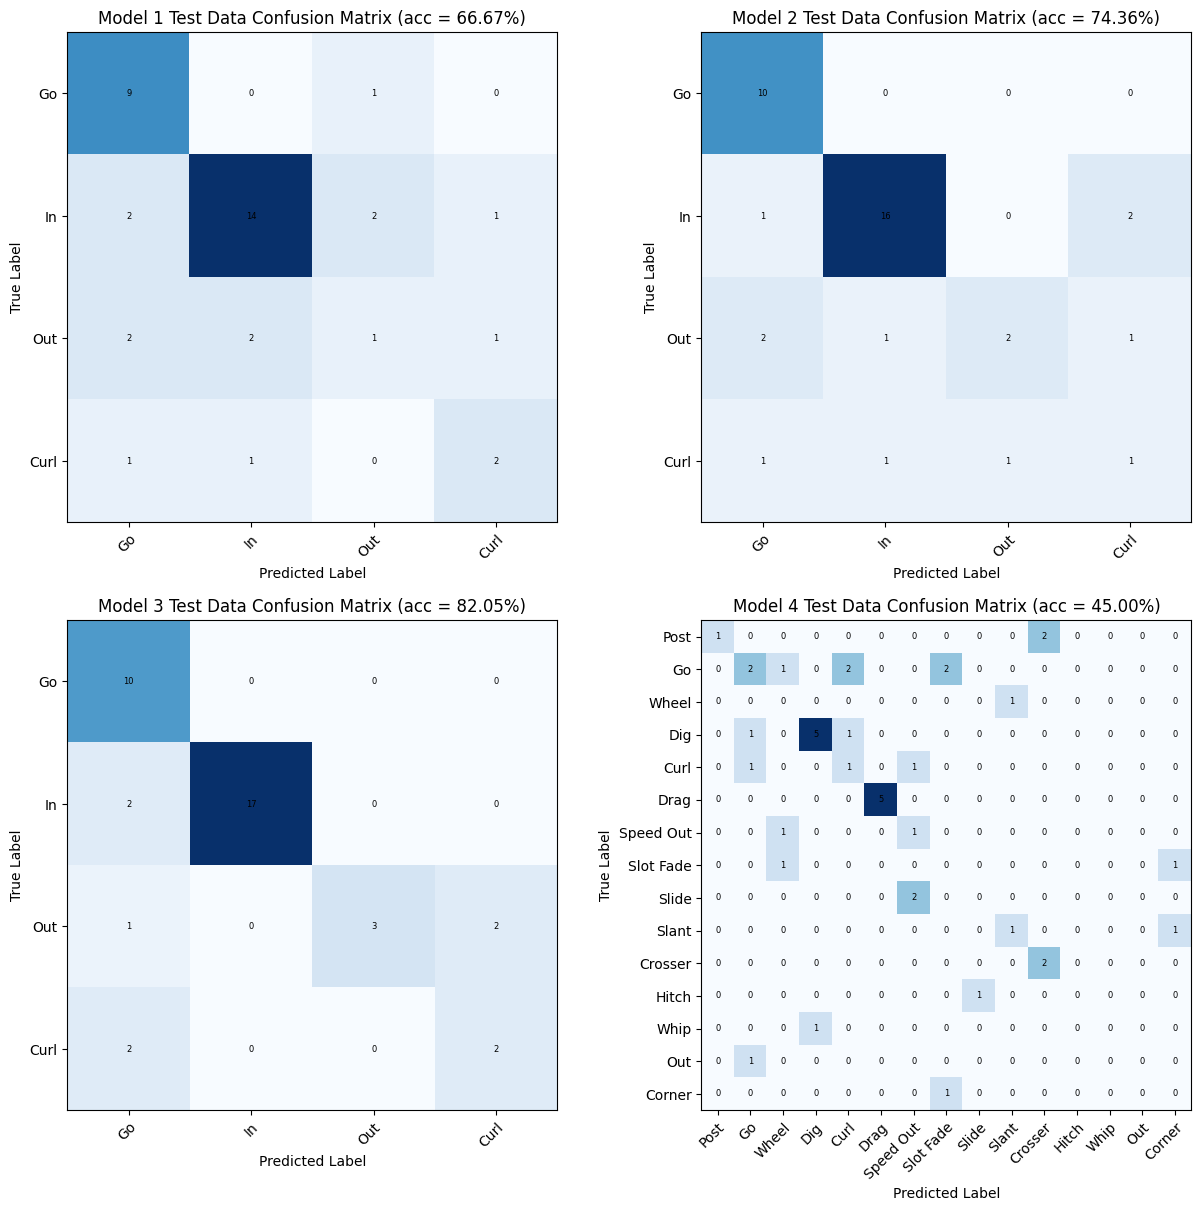

In [20]:
fig, axarr = plt.subplots(2, 2, figsize = (15, 14))
ax = axarr[0][0]
TrainEval1.plot_confusion_mat(model1_test_cm, ax, title = f"Model 1 Test Data Confusion Matrix (acc = {model1_test_acc:.2%})")
ax = axarr[0][1]
TrainEval2.plot_confusion_mat(model2_test_cm, ax, title = f"Model 2 Test Data Confusion Matrix (acc = {model2_test_acc:.2%})")
ax = axarr[1][0]
TrainEval3.plot_confusion_mat(model3_test_cm, ax, title = f"Model 3 Test Data Confusion Matrix (acc = {model3_test_acc:.2%})")
ax = axarr[1][1]
TrainEval4.plot_confusion_mat(model4_test_cm, ax, title = f"Model 4 Test Data Confusion Matrix (acc = {model4_test_acc:.2%})")

On test data, all models performed similarly to validation data, as expected. The confusion matrices give us some insight into where the models tended to miss, and it appears to happen most frequently on the labels we had less data on. Models 2 and 3 had a true positive rate of 100% on Go routes and 84% and 89% on In routes, respectively. Models 1-3 all performed worse on Out and Curl routes, never reaching a TPR of above 50%. Model 4 performed best on Dig, Drag, and Crosser routes, which is significant because they are very similar routes.

## Concluding Discussion
This project achieved some of its goals but failed at others. The biggest achievement was that every model showed considerable learning compared to their base rates, indicating that a task such as this is possible. One disappointment is that the accuracy on the first set of labels wasn't as high as I would've hoped. With these basic labels, I thought that the model would find it easy to differentiate between a WR moving in, out, straight, or stopping. However, I am confident that the issue could have been fixed with more data. As mentioned in the results, the models were significantly better at predicting routes with more data. The greatest sign of this was in Model 4, where it was able to distinguish Dig, Drag, and Crosser routes extremely well, even though they are all short to intermediate in-breaking routes. With more data, the model complexity could have been increased without fearing overfitting as much. That could've helped it differentiate more nuanced differences between labels in the second set. Since I did not use MSE as my loss function, I cannot compare my models to Scott's, but my accuracy on test data was greater than Kinley's.

## Group Contributions Statement

For this project, I, Parker Loupessis, with the help of the class notes and generative AI, where indicated, wrote all of the source code, performed all of the experiments, created the visualizations, and wrote the report. The major items that I completed with zero outside assistance include the data gathering, filtering, and prepping (the most time-consuming part was creating labels), formatting/organizing the code to follow the instructed structure, and the report. Everything else had at least minor assistance from generative AI or class notes. Comments in src code were created entirely by AI.

## References
Band, M. (2020, August 25). Next Gen stats: Intro to new route recognition model. NFL.com. https://www.nfl.com/news/next-gen-stats-intro-to-new-route-recognition-model 

Kinney, M. (2020). Template matching route classification. Journal of Quantitative Analysis in Sports, 16(2). https://doi.org/10.1515/jqas-2019-0051 

Scott, E., Mangum, J., & Anuredde. (2025, April 27). Predicting wide receiver routes in the NFL. Kaggle. https://www.kaggle.com/code/elliottscott774/predicting-wide-receiver-routes-in-the-nfl 

Sterken, N. (n.d.). RouteNet: a convolutional neural network for classifying routes. https://operations.nfl.com/media/3671/big-data-bowl-sterken.pdf 